## House Prices - Advanced Regression Techniques <br> 房价——高级回归技术

### Goal 目标

It is your job to predict the sales price for each house. For each Id in the test set, you must predict the value of the SalePrice variable.
你的任务是预测每栋房屋的售价。对于测试集中的每个 ID，你必须预测 SalePrice 变量的值。

API key = KGAT_53788d07f5f72126b602b031635897c1

## 1 Packages and data load 库与数据加载

In [96]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# config
sns.set_theme(style="whitegrid")

In [2]:
DATA_DIR = Path(r"house-prices")

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
description_path = DATA_DIR / "data_description.txt"

print("当前目录:", DATA_DIR.resolve())
print("train.csv:", train_path.exists())
print("test.csv :", test_path.exists())
print("description:", description_path.exists())

当前目录: C:\Users\Tolia\Documents\GitHub\ITMO-MA\EnterExam\ai\Practice\S1-1\house-prices
train.csv: True
test.csv : True
description: True


In [3]:
# NA_VALUES = []

train = pd.read_csv(train_path,keep_default_na=True) # na_values=NA_VALUES
test = pd.read_csv(test_path, keep_default_na=True) # na_values=NA_VALUES

train shape: (1460, 81)
test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## 2 Data quality analysis 数据质量检查

### 2.1 Data preview and columns classify 数据预览与分类检查

In [99]:
print("train shape:", train.shape)
print("test shape :", test.shape)

display(train.head())
display(test.head())

train shape: (1460, 81)
test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [100]:
print("--- ID/Target ---")
ID_COL = "Id"
TARGET_COL = "SalePrice"
print("Target:", TARGET_COL)
print("Target dtype:", train[TARGET_COL].dtype)

print("\n--- train.info() ---")
print(train.info())

--- ID/Target ---
Target: SalePrice
Target dtype: int64

--- train.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     146

### 2.2 Duplication check 重复记录与重复实体

In [69]:
ID_COL = "Id"

print("Total duplicated rows:", train.duplicated().sum())

print("Duplicated rows num by Id:", train[ID_COL].duplicated().sum())
print("Unique Id num:", train[ID_COL].nunique())
print("Total rows num:", len(train))

dup_ids = train.loc[train[ID_COL].duplicated(keep=False), ID_COL]
display(train[train[ID_COL].isin(dup_ids)].sort_values(ID_COL).head(20))


Total duplicated rows: 0
Duplicated rows num by Id: 0
Unique Id num: 1460
Total rows num: 1460


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


### 2.3 Missing value check 缺失值检查

**注意：缺失值不一定代表错误。**

House Prices 中某些空值实际上可能意味着“没有该设施”，例如没有车库、地下室、泳池等。因此真正处理前应该阅读 `data_description.txt`。

| Missing rate | Handle strategy            |
|--------------|----------------------------|
| <0.1%        | 可以考虑直接删除对应行                |
| 0.1% ~ 5%    | 优先考虑简单填充                   |
| 5% ~ 30%     | 根据特征语义选择填充策略               |
| >30%         | 重点判断 NA 是否具有业务含义，不能仅凭缺失率决定 |

In [58]:
# 生成缺省值报告表格
missing_report = pd.DataFrame({
    "dtype": train.dtypes,
    "missing_count": train.isna().sum(),
    "missing_rate": train.isna().mean()
})

# 过滤无缺省值的特征
missing_report = missing_report[
    missing_report["missing_count"] > 0
]

# 排序后输出
display(missing_report.sort_values(by="missing_rate", ascending=False))

,dtype,missing_count,missing_rate
PoolQC,object,1453,0.995205
MiscFeature,object,1406,0.963014
Alley,object,1369,0.937671
Fence,object,1179,0.807534
MasVnrType,object,872,0.597260
FireplaceQu,object,690,0.472603
LotFrontage,float64,259,0.177397
GarageType,object,81,0.055479
GarageYrBlt,float64,81,0.055479
GarageFinish,object,81,0.055479


### 2.4 Outliers check 异常值检查

- 数值型数据
  - 检查数值分布（散点图，直方图，箱线图）
- 类别型数据

In [105]:
print("\n--- 数值变量统计 ---")
display(train.describe())

print("\n--- 类别变量统计 ---")
display(train.describe(include=["object"]))


--- 数值变量统计 ---


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



--- 类别变量统计 ---


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


GrLivArea


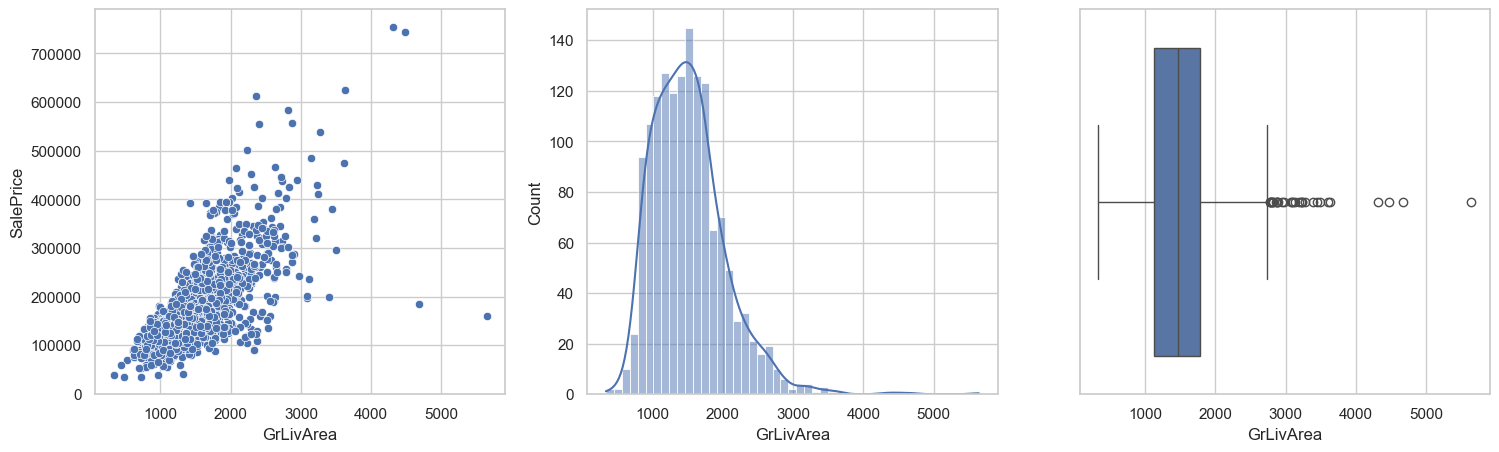

In [106]:
NUM_FEATURES = ['GrLivArea']

for feature in NUM_FEATURES:

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

    print(feature)

    sns.scatterplot(x=train[feature],y=train[TARGET_COL], ax=axes[0])
    sns.histplot(train[feature], kde=True, ax=axes[1])
    sns.boxplot(x=train[feature], ax=axes[2])

    plt.show()

## 3 数据提取与划分

### 3.1 特征与目标值提取

In [97]:
X = train.drop(columns=[ID_COL, TARGET_COL]).copy()
Y = train[TARGET_COL].copy()

X_train, X_valid, y_train, y_valid = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (1168, 79)
X_valid: (292, 79)
y_train: (1168,)
y_valid: (292,)


In [103]:
NUM_COL = train.select_dtypes(include=[np.number]).columns
OBJ_COL = train.select_dtypes(exclude=[np.number]).columns
print("Numerical Columns:", NUM_COL.tolist())
print("\nObjective Columns:", OBJ_COL.tolist())

Numerical Columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Objective Columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQ